## Data Cleaning & Preprocessing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

## load Dataset

In [5]:
df = sns.load_dataset("titanic")

## Initial Exploration

In [6]:
print("First 5 rows:\n", df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nNull Values:\n", df.isnull().sum())

First 5 rows:
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----  

## Handling Missing Values

In [12]:

# Check available columns
print("Available columns:", df.columns.tolist())


Available columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [17]:
# Fill age with MEDIAN
df['age'] = df['age'].fillna(df['age'].median())

# Fill fare with MEAN (if missing)
if df['fare'].isnull().sum() > 0:
    df['fare'] = df['fare'].fillna(df['fare'].mean())

# Fill embarked with MODE
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop deck column if it exists (too many missing values)
if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

print("\nNull Values After Handling:\n", df.isnull().sum())


Null Values After Handling:
 survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


## Encoding Categorical Variables

In [22]:

# Check columns before encoding
print("Columns in df:", df.columns.tolist())


Columns in df: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'embarked_Q', 'embarked_S']


In [23]:
# Label Encoding
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

# One Hot Encoding (only if embarked column still exists)
if 'embarked' in df.columns:
    df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

print("\nData after Encoding:\n", df.head())


Data after Encoding:
    survived  pclass  sex   age  sibsp  parch     fare  class    who  \
0         0       3    1  22.0      1      0   7.2500  Third    man   
1         1       1    0  38.0      1      0  71.2833  First  woman   
2         1       3    0  26.0      0      0   7.9250  Third  woman   
3         1       1    0  35.0      1      0  53.1000  First  woman   
4         0       3    1  35.0      0      0   8.0500  Third    man   

   adult_male  embark_town alive  alone  embarked_Q  embarked_S  
0        True  Southampton    no  False       False        True  
1       False    Cherbourg   yes  False       False       False  
2       False  Southampton   yes   True       False        True  
3       False  Southampton   yes  False       False        True  
4        True  Southampton    no   True       False        True  


## Feature Scaling

In [25]:
# Select numerical columns
num_cols = ['age', 'fare']

# Standardization
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("\nAfter Scaling:\n", df.head())


After Scaling:
    survived  pclass  sex       age  sibsp  parch      fare  class    who  \
0         0       3    1 -0.565736      1      0 -0.502445  Third    man   
1         1       1    0  0.663861      1      0  0.786845  First  woman   
2         1       3    0 -0.258337      0      0 -0.488854  Third  woman   
3         1       1    0  0.433312      1      0  0.420730  First  woman   
4         0       3    1  0.433312      0      0 -0.486337  Third    man   

   adult_male  embark_town alive  alone  embarked_Q  embarked_S  
0        True  Southampton    no  False       False        True  
1       False    Cherbourg   yes  False       False       False  
2       False  Southampton   yes   True       False        True  
3       False  Southampton   yes  False       False        True  
4        True  Southampton    no   True       False        True  


## Outlier Detection & Removal

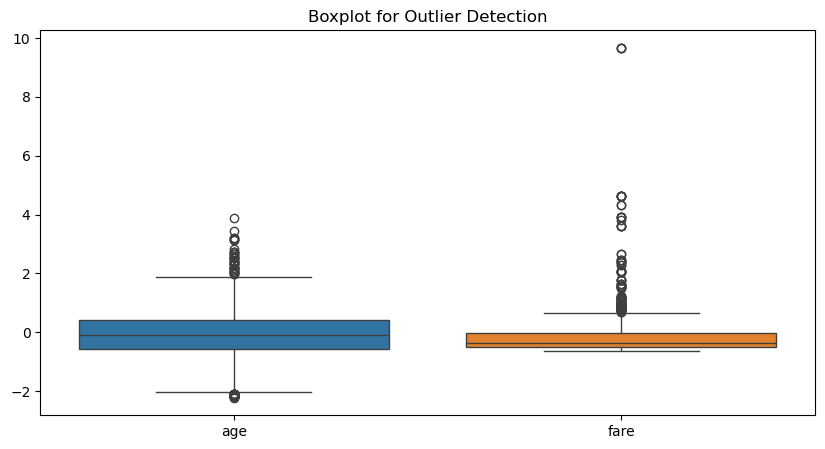

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['age','fare']])
plt.title("Boxplot for Outlier Detection")
plt.show()

In [29]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply on numerical columns
for col in ['age', 'fare']:
    df = remove_outliers(df, col)

print("\nShape after removing outliers:", df.shape)


Shape after removing outliers: (718, 15)


## Final Dataset

In [30]:
print("\nFinal Data:\n", df.head())


Final Data:
    survived  pclass  sex       age  sibsp  parch      fare  class    who  \
0         0       3    1 -0.565736      1      0 -0.502445  Third    man   
2         1       3    0 -0.258337      0      0 -0.488854  Third  woman   
3         1       1    0  0.433312      1      0  0.420730  First  woman   
4         0       3    1  0.433312      0      0 -0.486337  Third    man   
5         0       3    1 -0.104637      0      0 -0.478116  Third    man   

   adult_male  embark_town alive  alone  embarked_Q  embarked_S  
0        True  Southampton    no  False       False        True  
2       False  Southampton   yes   True       False        True  
3       False  Southampton   yes  False       False        True  
4        True  Southampton    no   True       False        True  
5        True   Queenstown    no   True        True       False  
